# Logistic Regression from Scratch
In this notebook, we will implement Logistic Regression from scratch using NumPy and Pandas. We will explore the mathematical foundations of the algorithm, visualize the data, and plot the decision boundary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Data
First, we load the dataset `Social_Network_Ads.csv` and extract our features (`X_train`) and labels (`y_train`). We also perform feature scaling to avoid numerical overflow during gradient descent.

In [2]:
data = pd.read_csv("Data_SET/Social_Network_Ads.csv")

X_train_raw = data[['Age', 'EstimatedSalary']].values
y_train = data['Purchased'].values


X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0)
X_train = (X_train_raw - X_mean) / X_std

m, n = X_train.shape
print(f"Number of training examples: {m}")
print(f"Number of features: {n}")

Number of training examples: 400
Number of features: 2


## 2. Visualize the Data
Let's plot the training data to see how the two classes are distributed.

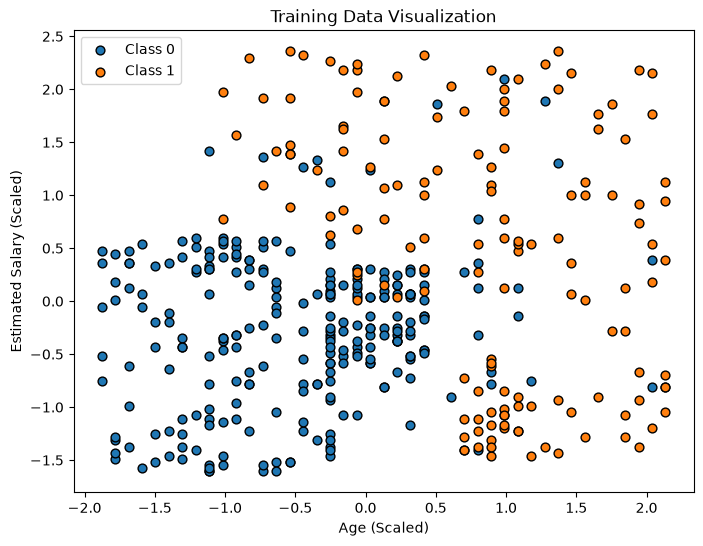

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=40, edgecolor='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=40, edgecolor='k')
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.title('Training Data Visualization')
plt.legend()
plt.show()

## 3. Sigmoid Function
The sigmoid function maps any real value to a value between 0 and 1, which represents the probability of the positive class.

Mathematically, the sigmoid function $\sigma(z)$ is defined as:
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

where $z$ is the linear combination of inputs and weights:
$$ z = \mathbf{w} \cdot \mathbf{x} + b $$

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Plot the Sigmoid Curve
We can visualize the sigmoid function to see how it squashes the input values.

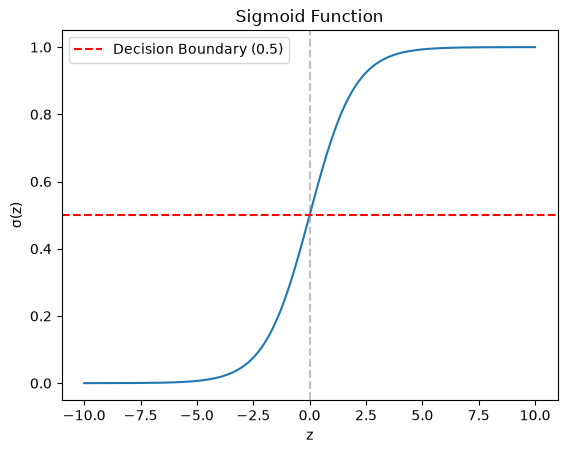

In [5]:
z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.legend()
plt.show()

## 4. Cost Function (Log Loss)
For Logistic Regression, we use the Log Loss (or Binary Cross-Entropy) function. It measures how well our predicted probabilities match the actual labels.

The cost function $J(\mathbf{w}, b)$ is computed over all $m$ training examples as:
$$ J(\mathbf{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1 - y^{(i)}) \log(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})) \right] $$

where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \sigma(\mathbf{w} \cdot \mathbf{x}^{(i)} + b)$

In [6]:
def cost_function(X, y, w, b):
    cost_sum = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    return (1/m) * cost_sum

## 5. Gradient Function
To minimize the cost function, we need to calculate its gradient (partial derivatives) with respect to the weights $\mathbf{w}$ and bias $b$.

The partial derivative with respect to the bias $b$ is:
$$ \frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) $$

The partial derivative with respect to each weight $w_j$ is:
$$ \frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_j^{(i)} $$

In [7]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0
    
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        
        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i, j]
            
    grad_b = (1/m) * grad_b
    grad_w = (1/m) * grad_w
    
    return grad_b, grad_w

## 6. Gradient Descent
We update the parameters iteratively using Gradient Descent. With learning rate $\alpha$, the update rules are:

$$ w_j = w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} $$
$$ b = b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} $$

We also save the cost history at each step to visualize its convergence later.

In [8]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0
    cost_history = []
    
    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        
        cost = cost_function(X, y, w, b)
        cost_history.append(cost)
        
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost}")
            
    return w, b, cost_history

## 7. Prediction
Once we have learned the optimal parameters $\mathbf{w}$ and $b$, we use them to predict the probability for new inputs. If the probability is $\ge 0.5$, we classify it as Class 1, otherwise Class 0.

$$ \hat{y}^{(i)} = \begin{cases} 1 & \text{if } \sigma(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \ge 0.5 \\ 0 & \text{otherwise} \end{cases} $$

In [9]:
def predict(X, w, b):
    preds = np.zeros(m)
    
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        preds[i] = 1 if g >= 0.5 else 0
        
    return preds

## 8. Train the Model
Now, let's set our learning rate and number of iterations, train the model, and evaluate its accuracy.

In [10]:
learning_rate = 0.01
iterations = 10000

final_w, final_b, cost_history = gradient_descent(X_train, y_train, learning_rate, iterations)

predictions = predict(X_train, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training accuracy: {accuracy:.2f}%")
print(f'\nFinal w: {final_w}')
print(f'Final b: {final_b:.4f}')

Iteration 0: Cost 0.6917549770222068
Iteration 1000: Cost 0.3864636327093949
Iteration 2000: Cost 0.36006229221321184
Iteration 3000: Cost 0.35233099587445277
Iteration 4000: Cost 0.34924922481829895
Iteration 5000: Cost 0.3478346824302851
Iteration 6000: Cost 0.3471318377473682
Iteration 7000: Cost 0.3467648994288209
Iteration 8000: Cost 0.3465669244234576
Iteration 9000: Cost 0.3464576509012795
Training accuracy: 84.50%

Final w: [2.37844967 1.19043252]
Final b: -1.1126


## 9. Cost over Training
To ensure that our gradient descent algorithm is working correctly, we can plot the cost at each iteration. We expect to see a smooth curve that decreases over time, indicating that our parameters are converging to the optimal values.

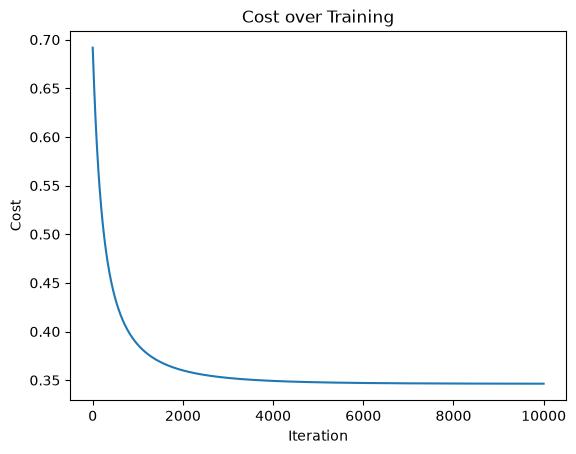

In [11]:
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost over Training')
plt.show()

## 10. Visualize Decision Boundary
The decision boundary occurs where $\sigma(z) = 0.5$, which means $z = 0$.
Therefore, the boundary is the line where: 
$$ w_1 x_1 + w_2 x_2 + b = 0 $$
Solving for $x_2$ to plot the line:
$$ x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2} $$

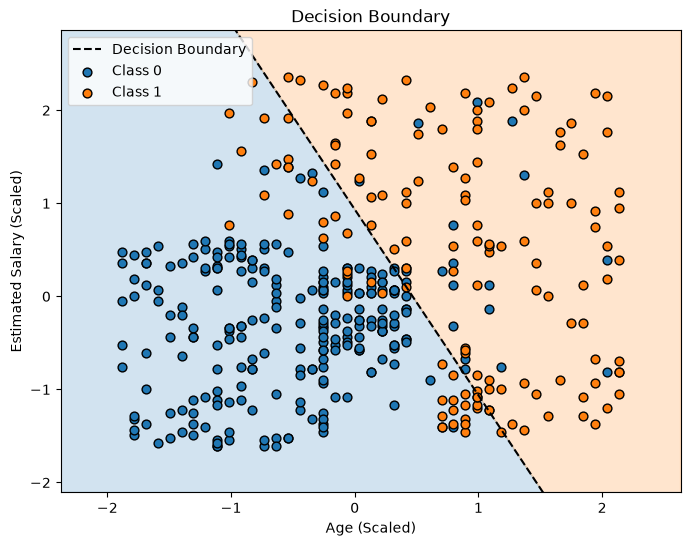

In [12]:
m_line = -final_w[0] / final_w[1]
c_line = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m_line * xd + c_line

plt.figure(figsize=(8, 6))
plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=40, edgecolor='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=40, edgecolor='k')

plt.title('Decision Boundary')
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.show()